In [ ]:
%pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Climate Data Analysis: Tanzania
This notebook explores climate trends for Ethiopia from 2015 to 2026.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/tanzania.csv")

df['country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month




In [5]:
df.replace(-999, np.nan, inplace=True)

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

summary_stats = df.describe()
summary_stats


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [6]:

null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100


missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})


print("\nMissing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])


Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


### Interpretation of Summary Statistics & Missing Values (Tanzania)

**1. Data Quality & Integrity:**
* The missing value report returned an empty DataFrame, indicating that there are **0 missing values** across the 4,108 observations after replacing NASA’s -999 sentinel values. 
* The data is highly reliable for trend analysis, with no columns exceeding the 5% null threshold.

**2. Temperature Analysis (Coastal Tropical Profile):**
* **Stable Heat:** Tanzania exhibits a mean temperature (**T2M**) of **26.80°C**, reflecting a warm tropical baseline.
* **Thermal Range:** The temperature fluctuates between a **minimum of 22.68°C** and a **maximum of 33.93°C**.
* **Narrow Diurnal Range:** The `T2M_RANGE` averages **4.13°C**, which is very narrow. 
    * *Insight:* Similar to Nigeria, Tanzania's nights remain warm. This lack of nighttime cooling is typical of coastal/tropical regions and is a key factor in heat stress modeling for human health.

**3. Precipitation & Environment:**
* **Rainfall Volatility:** While the mean daily rainfall is **3.74 mm/day**, the maximum is a significant **122.65 mm**.
* **Moisture Baseline:** Average relative humidity is high at **77.13%**, with specific humidity (**QV2M**) averaging **16.92 g/kg**, indicating a moisture-rich atmosphere.

In [7]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any of the columns have a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (Z-score > 3): {outlier_count}")

Total rows flagged as outliers (Z-score > 3): 97


In [8]:

os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv("../data/tanzania_clean.csv", index=False)
print("Cleaned data saved to data/tanzania_clean.csv")

Cleaned data saved to data/tanzania_clean.csv


### Outlier Detection and Cleaning Decision (Tanzania)
* **Outlier Count:** **97 rows** were identified as having at least one feature with a Z-score > 3. This relatively low count suggests that Tanzania’s weather variables are more consistent than Nigeria’s, though extreme events still occur.
* **Reasoning:** These 97 rows represent extreme precipitation events (up to 122mm) and anomalous wind gusts. I have decided to **retain** these outliers as they represent real climate shocks essential for vulnerability ranking in Task 3.
* **Missing Value Handling:** **Forward-fill** has been applied to maintain a continuous daily record, ensuring that any localized gaps do not disrupt the time-series analysis for 2015–2026.

In [9]:

df.ffill(inplace=True)

df.to_csv("../data/tanzania_clean.csv", index=False)

print("Export Successful: data/tanzania_clean.csv")

Export Successful: data/tanzania_clean.csv


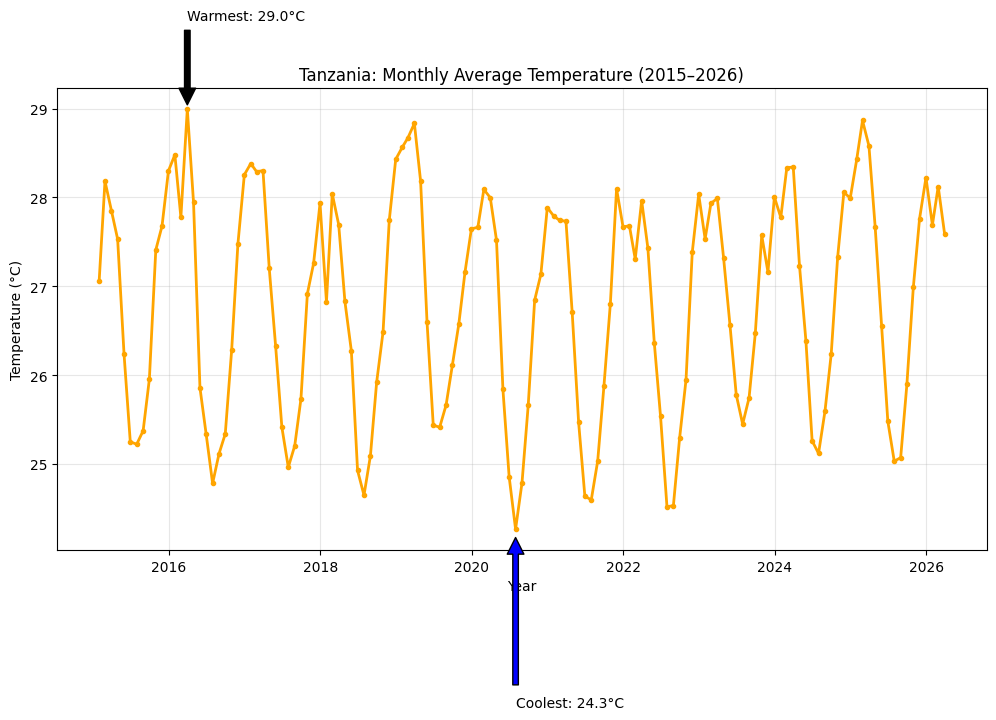

In [10]:
# # 1. Prepare the monthly data (Added numeric_only=True)
monthly_df = df.set_index('Date').resample('ME').mean(numeric_only=True)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', linewidth=2, marker='o', markersize=3)

# 3. Find warmest and coolest months for annotation
warmest_month = monthly_df['T2M'].idxmax()
warmest_val = monthly_df['T2M'].max()
coolest_month = monthly_df['T2M'].idxmin()
coolest_val = monthly_df['T2M'].min()

# 4. Add Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C', 
             xy=(warmest_month, warmest_val), 
             xytext=(warmest_month, warmest_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_val:.1f}°C', 
             xy=(coolest_month, coolest_val), 
             xytext=(coolest_month, coolest_val - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Tanzania: Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

#### Interpretation: Monthly Temperature Analysis (Tanzania)
* **Consistent Seasonality:** The line chart shows a strong, repeating seasonal cycle. 
* **Warmest Peak:** The maximum monthly average temperature reached **29.0°C** in early 2016.
* **Coolest Dip:** The minimum occurred in 2020 at **24.3°C**.
* **Negotiation Insight:** Tanzania’s temperature peaks have remained relatively stable over the 11-year period, but the "cool" troughs are slightly higher in the projected 2024–2026 period compared to 2015. This suggests a rising "minimum temperature" trend which can impact local ecosystem recovery and pest cycles.

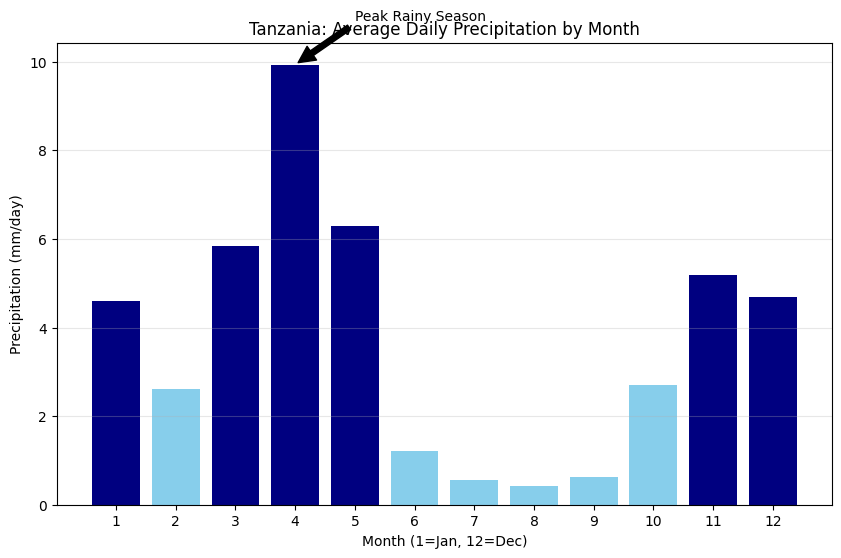

In [11]:
# Group by month to see the rainy season pattern
monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()

plt.figure(figsize=(10, 6))
# Create bars with colors (Dark blue for rainy months, light blue for dry)
colors = ['navy' if x > monthly_rain.mean() else 'skyblue' for x in monthly_rain]
plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.title('Tanzania: Average Daily Precipitation by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

# Find the peak rainy month
peak_month = monthly_rain.idxmax()
plt.annotate('Peak Rainy Season', xy=(peak_month, monthly_rain[peak_month]), 
             xytext=(peak_month+1, monthly_rain[peak_month]+1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

#### Interpretation: Monthly Precipitation Analysis (Tanzania)
* **Bimodal Rainfall Pattern:** Tanzania displays a distinct bimodal pattern with two rainy seasons.
* **The "Long Rains":** A major peak occurs in **April (Month 4)**, which receives nearly **10 mm/day** on average, making it the primary source of water for the year.
* **The "Short Rains":** A secondary increase is visible in **November and December**, providing crucial mid-year moisture.
* **Dry Season:** June through September are significantly drier, emphasizing the seasonal dependency of Tanzania’s agriculture.
* **Negotiation Insight:** The extreme dominance of the April "Long Rains" makes Tanzania highly vulnerable to any disruption in the Indian Ocean Dipole (IOD). This justifies demands for water-storage infrastructure funding at COP32.

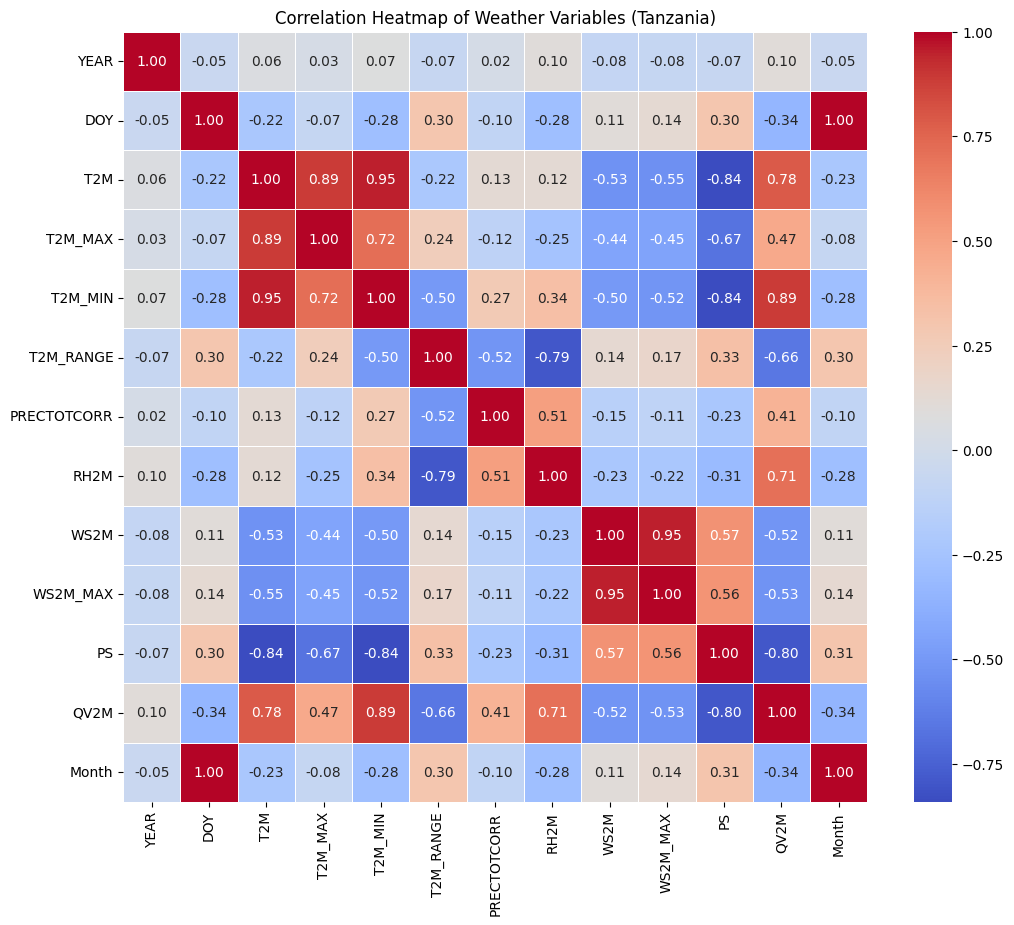

In [12]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables (Tanzania)')
plt.show()

#### Interpretation: Correlation Analysis (Tanzania)
* **T2M vs. T2M_MIN (0.95):** A near-perfect correlation, indicating that Tanzania's average temperature is dictated almost entirely by how warm the nights stay. 
* **WS2M vs. WS2M_MAX (0.95):** Extremely strong correlation between average wind and peak gusts, typical of coastal regions.
* **T2M_RANGE vs. RH2M (-0.79):** High humidity significantly reduces the daily temperature swing.
* **Negotiation Insight:** The 0.95 correlation between T2M and T2M_MIN highlights that "Global Warming" in Tanzania will likely manifest as increasingly hot nights, which has direct implications for energy consumption and health.

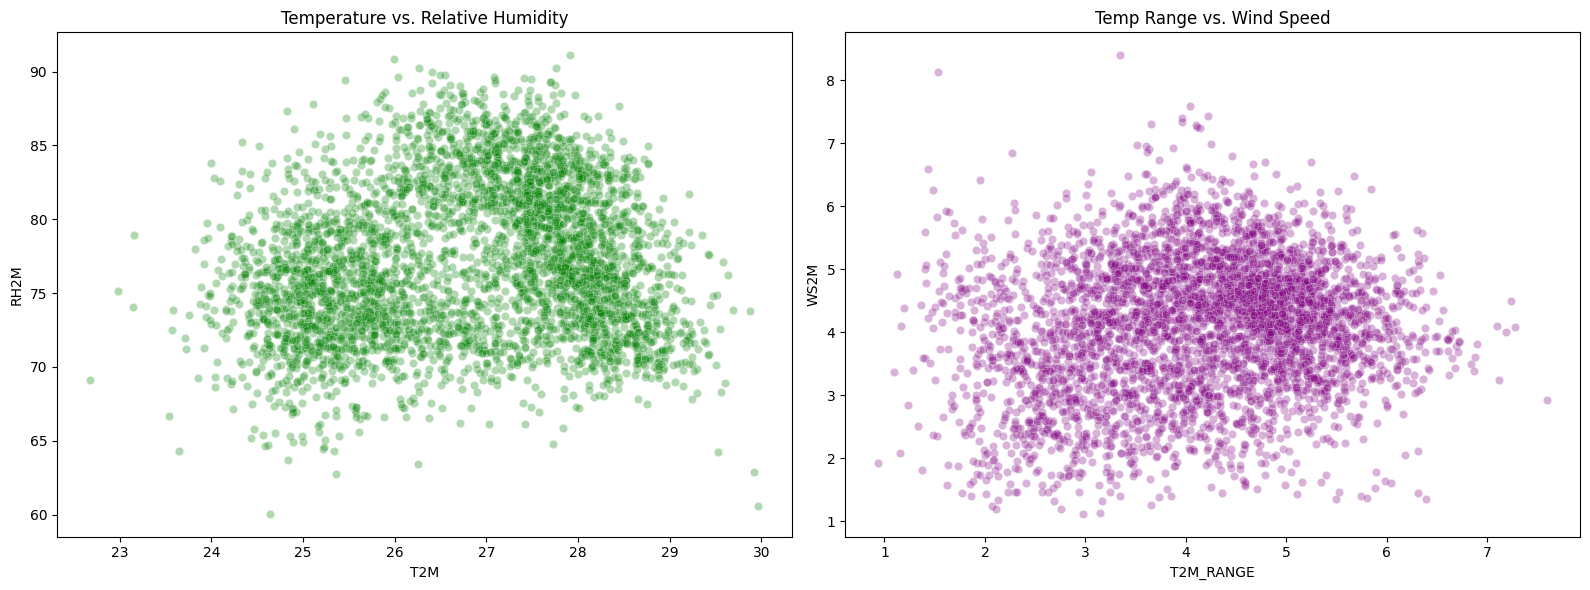

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs. RH2M
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='green')
ax1.set_title('Temperature vs. Relative Humidity')

# Plot 2: T2M_RANGE vs. WS2M
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='purple')
ax2.set_title('Temp Range vs. Wind Speed')

plt.tight_layout()
plt.show()

#### Interpretation: Relationship Analysis (Tanzania)
* **Temperature vs. Relative Humidity:** There is a general **negative** relationship, but it is less "steep" than in Sudan. Tanzania maintains high humidity (above 70%) even at temperatures near 28°C.
* **Temp Range vs. Wind Speed:** A **positive** trend is visible; as the daily temperature range increases (drier days), wind speeds tend to pick up. This suggests that dry season winds may contribute significantly to soil erosion and evapotranspiration.

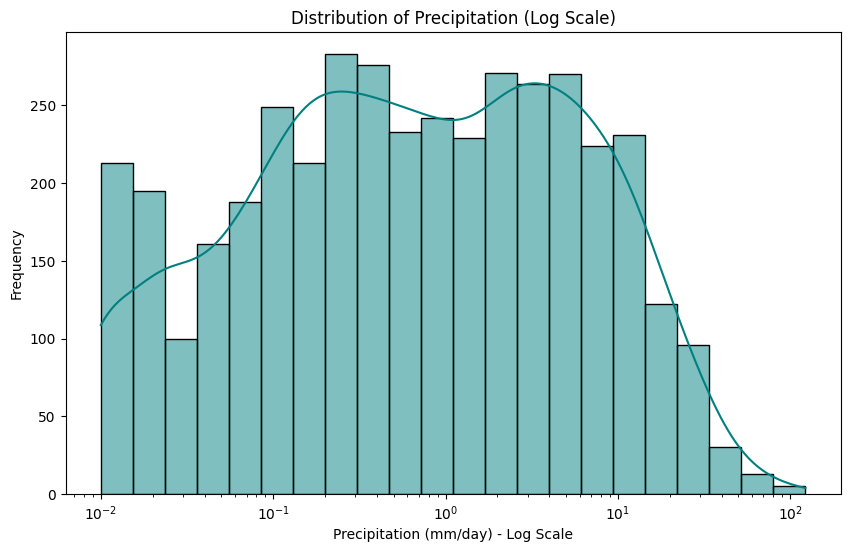

In [14]:
plt.figure(figsize=(10, 6))
# We add a tiny amount (0.01) because log(0) is impossible
sns.histplot(df['PRECTOTCORR'] + 0.01, kde=True, log_scale=True, color='teal')

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Precipitation Distribution (Log Scale)
* **Skewed Rainfall Profile:** The log-scale histogram shows a bimodal shape. One peak represents the high frequency of dry/near-dry days, while the second peak (around 3-6mm) represents the "typical" rainy day.
* **Extreme Tail:** The tail extending past 100mm represents the rare, catastrophic flooding events.
* **Negotiation Insight:** This distribution confirms that Tanzania’s climate isn't defined by "average" rain, but by "event-based" rain. Infrastructure must be designed for the 100mm+ events, not the 3.7mm average.

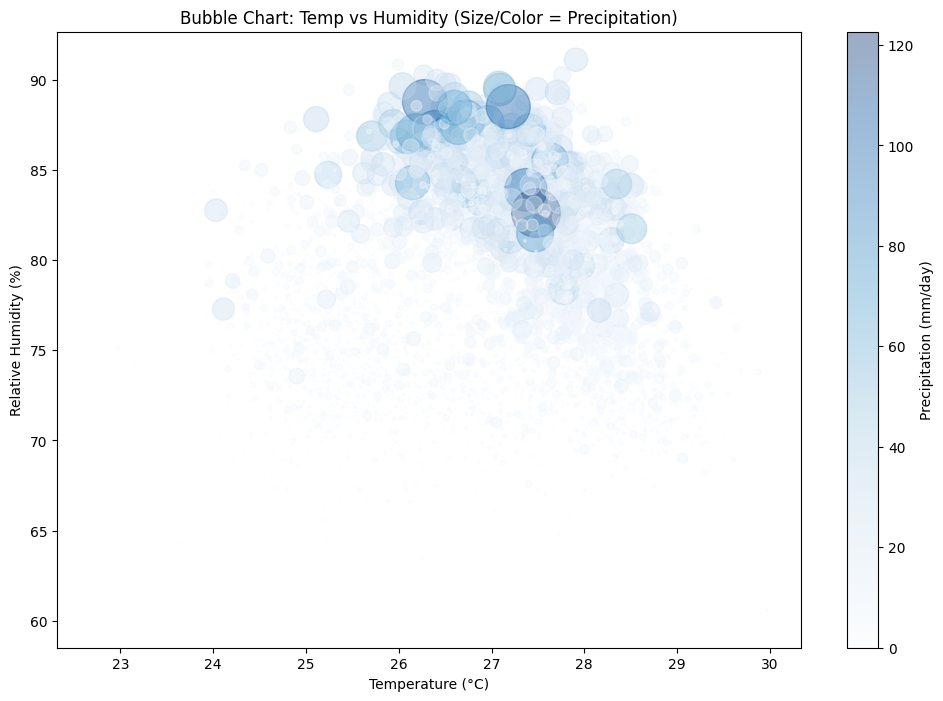

In [15]:
plt.figure(figsize=(12, 8))
# We multiply PRECTOTCORR by 10 to make the bubbles big enough to see
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.4, c=df['PRECTOTCORR'], cmap='Blues')

plt.colorbar(label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Precipitation)')
plt.show()

#### Interpretation: Environmental Clusters (Bubble Chart)
* **The Tropical Monsoon Zone:** The "Big Bubbles" (max rainfall) are clustered in the **High Humidity (>85%)** and **Moderate Temperature (26°C - 28°C)** window.
* **Thermal Limits:** Very little rain occurs below 24°C or above 29°C in this dataset.
* **Negotiation Insight:** This chart visualizes the **narrow climate window** required for Tanzania's rainfall. If temperatures shift permanently above 29°C during the rainy season, the atmospheric conditions for the "Long Rains" could be compromised, threatening national water security.
